In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
balanced_train = pd.read_csv(
    "train_fraud_balanced.csv"
)

validation_data = pd.read_csv(
    "validation_fraud.csv"
)

print("Training dataset:", balanced_train.shape)
print("Validation dataset:", validation_data.shape)

Training dataset: (79328, 45)
Validation dataset: (8648, 45)


In [4]:
if "is_fraud" not in balanced_train.columns:
    raise ValueError(
        "is_fraud column is missing from training data."
    )

if "is_fraud" not in validation_data.columns:
    raise ValueError(
        "is_fraud column is missing from validation data."
    )

print("Target column is available.")

Target column is available.


In [5]:
X_train = balanced_train.drop(
    columns=["is_fraud"]
)

y_train = balanced_train["is_fraud"]

X_validation = validation_data.drop(
    columns=["is_fraud"]
)

y_validation = validation_data["is_fraud"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

X_train: (79328, 44)
y_train: (79328,)
X_validation: (8648, 44)
y_validation: (8648,)


In [6]:
common_columns = [
    column for column in X_train.columns
    if column in X_validation.columns
]

X_train = X_train[common_columns].copy()
X_validation = X_validation[common_columns].copy()

print("Number of common features:", len(common_columns))

Number of common features: 44


In [7]:
for column in common_columns:

    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce"
    )

    X_validation[column] = pd.to_numeric(
        X_validation[column],
        errors="coerce"
    )

print("Features converted to numeric.")

Features converted to numeric.


In [8]:
usable_columns = [
    column for column in X_train.columns
    if X_train[column].notna().any()
]

X_train = X_train[usable_columns].copy()
X_validation = X_validation[usable_columns].copy()

print("Usable features:", len(usable_columns))
print(usable_columns)

Usable features: 22
['amount', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'transaction_hour', 'transaction_day', 'transaction_month', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'login_attempts', 'account_age_days', 'email_age_days', 'failed_payment_attempts', 'customer_balance', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location']


In [9]:
y_train = pd.to_numeric(
    y_train,
    errors="coerce"
)

y_validation = pd.to_numeric(
    y_validation,
    errors="coerce"
)

valid_train_rows = y_train.notna()
valid_validation_rows = y_validation.notna()

X_train = X_train.loc[
    valid_train_rows
].reset_index(drop=True)

y_train = y_train.loc[
    valid_train_rows
].astype(int).reset_index(drop=True)

X_validation = X_validation.loc[
    valid_validation_rows
].reset_index(drop=True)

y_validation = y_validation.loc[
    valid_validation_rows
].astype(int).reset_index(drop=True)

print("Training classes:")
print(y_train.value_counts())

print("\nValidation classes:")
print(y_validation.value_counts())

Training classes:
is_fraud
0    39664
1    39664
Name: count, dtype: int64

Validation classes:
is_fraud
0    8499
1     149
Name: count, dtype: int64


In [10]:
training_medians = X_train.median()

X_train = X_train.fillna(
    training_medians
)

X_validation = X_validation.fillna(
    training_medians
)

# Extra protection for any remaining missing values
X_train = X_train.fillna(0)
X_validation = X_validation.fillna(0)

print(
    "Training missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Validation missing values:",
    X_validation.isnull().sum().sum()
)

Training missing values: 0
Validation missing values: 0


In [11]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [12]:
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_validation, y_validation)
    ],
    verbose=False
)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [13]:
xgb_predictions = xgb_model.predict(
    X_validation
)

xgb_probabilities = xgb_model.predict_proba(
    X_validation
)[:, 1]

print("Predictions created successfully!")

Predictions created successfully!


In [14]:
xgb_accuracy = accuracy_score(
    y_validation,
    xgb_predictions
)

xgb_precision = precision_score(
    y_validation,
    xgb_predictions,
    zero_division=0
)

xgb_recall = recall_score(
    y_validation,
    xgb_predictions,
    zero_division=0
)

xgb_f1 = f1_score(
    y_validation,
    xgb_predictions,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_validation,
    xgb_probabilities
)

print("XGBOOST FRAUD DETECTION RESULTS")
print("--------------------------------")
print("Accuracy:", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall:", round(xgb_recall, 4))
print("F1 Score:", round(xgb_f1, 4))
print("ROC-AUC:", round(xgb_roc_auc, 4))

XGBOOST FRAUD DETECTION RESULTS
--------------------------------
Accuracy: 0.8392
Precision: 0.0407
Recall: 0.3691
F1 Score: 0.0733
ROC-AUC: 0.6465


In [15]:
print(
    classification_report(
        y_validation,
        xgb_predictions,
        labels=[0, 1],
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.99      0.85      0.91      8499
       Fraud       0.04      0.37      0.07       149

    accuracy                           0.84      8648
   macro avg       0.51      0.61      0.49      8648
weighted avg       0.97      0.84      0.90      8648



In [16]:
xgb_confusion = confusion_matrix(
    y_validation,
    xgb_predictions,
    labels=[0, 1]
)

print(xgb_confusion)

[[7202 1297]
 [  94   55]]


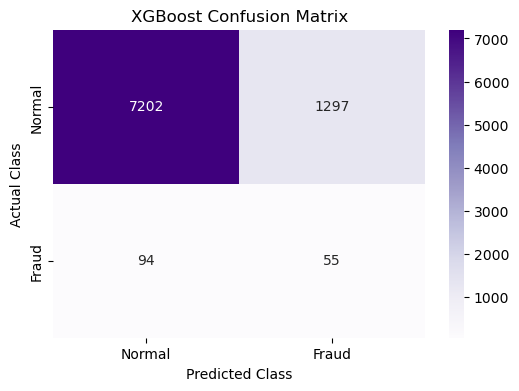

In [17]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    xgb_confusion,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

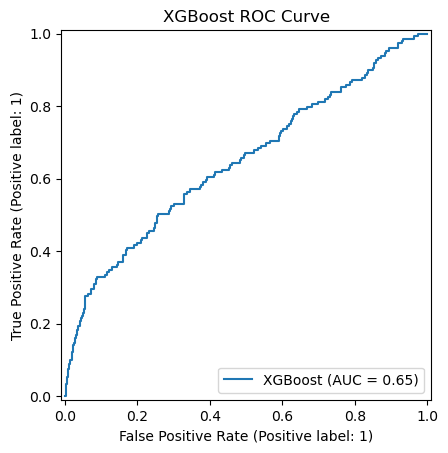

In [18]:
RocCurveDisplay.from_predictions(
    y_validation,
    xgb_probabilities,
    name="XGBoost"
)

plt.title("XGBoost ROC Curve")
plt.show()

In [19]:
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

xgb_importance.head(10)

,feature,importance
0,risk_score,0.110964
1,transactions_last_24h,0.056807
2,receiver_balance_after,0.053631
3,email_age_days,0.048560
4,average_amount_30d,0.047244
5,account_age_days,0.045578
6,transaction_day,0.043427
7,transaction_hour,0.043073
8,amount,0.042603
9,distance_from_home_km,0.042322


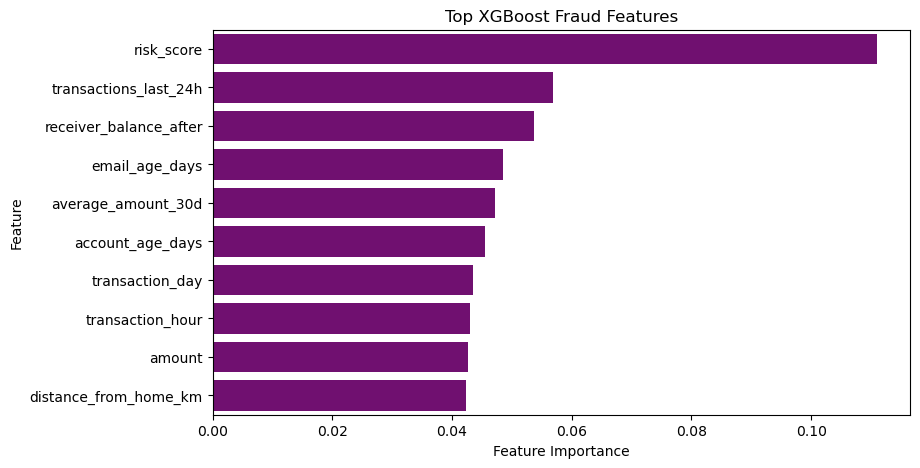

In [20]:
top_features = xgb_importance.head(10)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    color="purple"
)

plt.title("Top XGBoost Fraud Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
xgb_results = pd.DataFrame({
    "model": ["XGBoost"],
    "accuracy": [xgb_accuracy],
    "precision": [xgb_precision],
    "recall": [xgb_recall],
    "f1_score": [xgb_f1],
    "roc_auc": [xgb_roc_auc]
})

xgb_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,XGBoost,0.8392,0.0407,0.3691,0.0733,0.6465


In [22]:
xgb_results.to_csv(
    "xgboost_fraud_results.csv",
    index=False
)

xgb_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

print("XGBoost results saved successfully!")

XGBoost results saved successfully!


In [23]:
xgb_model.save_model(
    "xgboost_fraud_model.json"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!
